In [12]:
# =============================================================================
# DATATHON 2026 — Sales Forecasting Pipeline (Improved)
# Dựa trên notebook gốc của Thu, nâng cấp toàn diện:
#   + Fix stacking leakage (OOF đúng chuẩn)
#   + Bỏ generate_future_promos() giả định
#   + Thêm Vietnam holidays cho Prophet (Tết Nguyên Đán, etc.)
#   + Thêm features: quarter, lag_365, EWMA, month_start/end, Tết flag
#   + TimeSeriesSplit cross-validation đúng chiều thời gian
#   + SHAP values cho explainability (báo cáo kỹ thuật)
#   + Retrain pipeline sạch trên full data
# =============================================================================
 
# %% [1] — Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
 
from lightgbm import LGBMRegressor
import xgboost as xgb
from catboost import CatBoostRegressor
from prophet import Prophet
 
# SHAP — chạy `pip install shap` nếu chưa có
import shap
 
# Optuna — uncomment nếu muốn tune hyperparams tự động
# import optuna
# optuna.logging.set_verbosity(optuna.logging.WARNING)
 
RANDOM_SEED = 42
DATA_DIR = '../data'   # <-- sửa path nếu cần

In [13]:
# %% [2] — Load data
print("Loading data...")
df = pd.read_csv(os.path.join(DATA_DIR, 'raw', 'sales.csv'), parse_dates=['Date'])
promo = pd.read_csv(os.path.join(DATA_DIR, 'raw', 'promotions.csv'),
                    parse_dates=['start_date', 'end_date'])
sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'raw', 'sample_submission.csv'),
                         parse_dates=['Date'])
 
df = df.sort_values('Date').reset_index(drop=True)
print(f"Sales train: {df['Date'].min().date()} → {df['Date'].max().date()}, {len(df)} rows")
print(f"Promotions: {len(promo)} records")
print(f"Test period: {sample_sub['Date'].min().date()} → {sample_sub['Date'].max().date()}")
 

Loading data...
Sales train: 2012-07-04 → 2022-12-31, 3833 rows
Promotions: 50 records
Test period: 2023-01-01 → 2024-07-01


In [14]:
# %% [3] — Vietnam holidays cho Prophet
# Tết Nguyên Đán (ngày đầu năm âm lịch) — hardcode từng năm vì lunar calendar
# Window: 3 ngày trước đến 7 ngày sau (thực tế nghỉ Tết kéo dài)
TET_DATES = {
    2013: '2013-02-10', 2014: '2014-01-31', 2015: '2015-02-19',
    2016: '2016-02-08', 2017: '2017-01-28', 2018: '2018-02-16',
    2019: '2019-02-05', 2020: '2020-01-25', 2021: '2021-02-12',
    2022: '2022-02-01', 2023: '2023-01-22', 2024: '2024-02-10',
}
 
def make_vietnam_holidays():
    """Tạo DataFrame holidays cho Prophet gồm Tết + các ngày lễ cố định."""
    rows = []
 
    # Tết Nguyên Đán — window rộng vì ảnh hưởng lớn đến doanh thu
    for year, tet_str in TET_DATES.items():
        tet = pd.Timestamp(tet_str)
        for delta in range(-3, 8):  # 3 ngày trước, 7 ngày sau
            rows.append({
                'holiday': 'Tet_Nguyen_Dan',
                'ds': tet + pd.Timedelta(days=delta),
                'lower_window': 0,
                'upper_window': 0,
            })
 
    # Ngày lễ cố định theo dương lịch (2012–2024)
    fixed_holidays = {
        'New_Year':         '01-01',
        'Hung_Kings_Day':   '04-18',  # 10/3 âm — dùng ngày dương trung bình
        'Reunification_Day':'04-30',
        'Labor_Day':        '05-01',
        'National_Day':     '09-02',
        'Sale_1111':        '11-11',  # Double 11 — lễ hội mua sắm
        'Sale_1212':        '12-12',  # Double 12
        'Christmas_Eve':    '12-24',
        'Christmas':        '12-25',
        'New_Year_Eve':     '12-31',
    }
    for year in range(2012, 2025):
        for name, mmdd in fixed_holidays.items():
            try:
                rows.append({
                    'holiday': name,
                    'ds': pd.Timestamp(f'{year}-{mmdd}'),
                    'lower_window': 0,
                    'upper_window': 1,
                })
            except ValueError:
                pass  # bỏ qua ngày không hợp lệ
 
    return pd.DataFrame(rows).drop_duplicates(subset=['holiday', 'ds'])
 
vn_holidays = make_vietnam_holidays()
print(f"Vietnam holidays: {len(vn_holidays)} entries, {vn_holidays['holiday'].nunique()} types")
 
 

Vietnam holidays: 262 entries, 11 types


In [15]:
# %% [4] — Promotion features (dùng data thật, KHÔNG tự bịa)
def create_promotion_features(promo_df, date_range):
    """
    Tạo daily promotion features từ promotions.csv thật.
    Không giả định promotions tương lai.
    Ngày nào không có promo → tất cả = 0.
    """
    daily = pd.DataFrame({'Date': date_range})
    active_promos = []
 
    for _, row in promo_df.iterrows():
        mask = (daily['Date'] >= row['start_date']) & (daily['Date'] <= row['end_date'])
        for d in daily.loc[mask, 'Date']:
            active_promos.append({
                'Date': d,
                'promo_id': row['promo_id'],
                'promo_type': row['promo_type'],
                'discount_value': row['discount_value'],
                'stackable_flag': row['stackable_flag'],
                'applicable_category': row['applicable_category'],
                'promo_channel': row['promo_channel'],
                'min_order_value': row['min_order_value'],
            })
 
    if not active_promos:
        daily[['num_active_promos', 'num_promo_percentage', 'num_promo_fixed',
               'avg_discount_value', 'max_discount_value', 'has_stackable',
               'num_specific_category_promos', 'min_order_value_mean',
               'channel_all_channels', 'channel_email', 'channel_in_store',
               'channel_online', 'channel_social_media']] = 0
        return daily
 
    adf = pd.DataFrame(active_promos)
 
    num_active   = adf.groupby('Date')['promo_id'].nunique().rename('num_active_promos')
    avg_discount = adf.groupby('Date')['discount_value'].mean().rename('avg_discount_value')
    max_discount = adf.groupby('Date')['discount_value'].max().rename('max_discount_value')
    has_stack    = adf.groupby('Date')['stackable_flag'].max().rename('has_stackable')
    specific_cat = adf.groupby('Date')['applicable_category'].apply(
        lambda x: x.notna().sum()).rename('num_specific_category_promos')
    min_ord_mean = adf.groupby('Date')['min_order_value'].mean().rename('min_order_value_mean')
 
    ptype = adf.groupby(['Date', 'promo_type']).size().unstack(fill_value=0)
    for col in ['percentage', 'fixed']:
        if col not in ptype.columns:
            ptype[col] = 0
    ptype.columns = ['num_promo_' + c for c in ptype.columns]
 
    channel_dum = pd.get_dummies(adf[['Date', 'promo_channel']], columns=['promo_channel'], prefix='channel')
    channel_cols = [c for c in channel_dum.columns if c.startswith('channel_')]
    channel_daily = channel_dum.groupby('Date')[channel_cols].max()  # max vì binary
 
    daily = daily.set_index('Date')
    for feat in [num_active, avg_discount, max_discount, has_stack,
                 specific_cat, min_ord_mean, ptype, channel_daily]:
        daily = daily.join(feat, how='left')
    daily = daily.fillna(0).reset_index()
 
    # Đảm bảo tất cả channel columns tồn tại
    for ch in ['channel_all_channels', 'channel_email', 'channel_in_store',
               'channel_online', 'channel_social_media']:
        if ch not in daily.columns:
            daily[ch] = 0
 
    return daily
 
# Tạo promo features cho toàn bộ period (train + test) dùng data thật
all_dates = pd.date_range(df['Date'].min(), sample_sub['Date'].max(), freq='D')
promo_features = create_promotion_features(promo, all_dates)
print(f"Promo features: {promo_features.shape}, columns: {[c for c in promo_features.columns if c != 'Date']}")
 

Promo features: (4381, 14), columns: ['num_active_promos', 'avg_discount_value', 'max_discount_value', 'has_stackable', 'num_specific_category_promos', 'min_order_value_mean', 'num_promo_fixed', 'num_promo_percentage', 'channel_all_channels', 'channel_email', 'channel_in_store', 'channel_online', 'channel_social_media']


In [16]:
# %% [4.5] — Fix: Chuyển channel columns sang integer
# Đảm bảo các cột channel là số 0/1
channel_cols = ['channel_all_channels', 'channel_email', 'channel_in_store', 
                'channel_online', 'channel_social_media']

for col in channel_cols:
    if col in promo_features.columns:
        # Chuyển True/False thành 1/0, hoặc string thành int
        promo_features[col] = promo_features[col].astype(int)
    else:
        promo_features[col] = 0

print(f"Fixed channel columns: {[col for col in channel_cols if col in promo_features.columns]}")

Fixed channel columns: ['channel_all_channels', 'channel_email', 'channel_in_store', 'channel_online', 'channel_social_media']


In [17]:
# %% [5] — Merge & Feature Engineering
data = df.merge(promo_features, on='Date', how='left')
 
# --- Date features ---
data['year']          = data['Date'].dt.year
data['month']         = data['Date'].dt.month
data['day']           = data['Date'].dt.day
data['quarter']       = data['Date'].dt.quarter          # MỚI
data['dayofweek']     = data['Date'].dt.dayofweek
data['dayofyear']     = data['Date'].dt.dayofyear
data['weekofyear']    = data['Date'].dt.isocalendar().week.astype(int)
data['is_weekend']    = data['dayofweek'].isin([5, 6]).astype(int)
data['is_month_start']= data['Date'].dt.is_month_start.astype(int)  # MỚI
data['is_month_end']  = data['Date'].dt.is_month_end.astype(int)    # MỚI
data['is_quarter_end']= data['Date'].dt.is_quarter_end.astype(int)  # MỚI
 
# Fourier encoding cho seasonality (tốt hơn raw dayofyear)
data['sin_day']   = np.sin(2 * np.pi * data['dayofyear'] / 365.25)
data['cos_day']   = np.cos(2 * np.pi * data['dayofyear'] / 365.25)
data['sin_week']  = np.sin(2 * np.pi * data['dayofweek'] / 7)
data['cos_week']  = np.cos(2 * np.pi * data['dayofweek'] / 7)
data['sin_month'] = np.sin(2 * np.pi * data['month'] / 12)
data['cos_month'] = np.cos(2 * np.pi * data['month'] / 12)
 
# Holidays Việt Nam (fixed dates)
holiday_mmdd = {'01-01', '04-30', '05-01', '09-02', '11-11', '12-12', '12-24', '12-25', '12-31'}
data['is_holiday'] = data['Date'].dt.strftime('%m-%d').isin(holiday_mmdd).astype(int)
 
# Tết flag (MỚI) — 7 ngày window quanh Tết
tet_dates_set = set()
for tet_str in TET_DATES.values():
    tet = pd.Timestamp(tet_str)
    for d in range(-3, 8):
        tet_dates_set.add(tet + pd.Timedelta(days=d))
data['is_tet_period'] = data['Date'].isin(tet_dates_set).astype(int)
 
# --- Lag & Rolling features ---
lags    = [1, 2, 3, 7, 14, 30, 60, 90, 365]
windows = [7, 14, 30, 60]
 
for lag in lags:
    data[f'Revenue_lag_{lag}'] = data['Revenue'].shift(lag)
    data[f'COGS_lag_{lag}']    = data['COGS'].shift(lag)
 
for w in windows:
    # Rolling mean/std (shift(1) để tránh leakage)
    data[f'Revenue_roll_mean_{w}'] = data['Revenue'].shift(1).rolling(w).mean()
    data[f'Revenue_roll_std_{w}']  = data['Revenue'].shift(1).rolling(w).std()
    data[f'COGS_roll_mean_{w}']    = data['COGS'].shift(1).rolling(w).mean()
    data[f'COGS_roll_std_{w}']     = data['COGS'].shift(1).rolling(w).std()
 
# EWMA — Exponential Weighted Moving Average (MỚI, tốt hơn simple rolling)
for span in [7, 30]:
    data[f'Revenue_ewm_{span}'] = data['Revenue'].shift(1).ewm(span=span).mean()
    data[f'COGS_ewm_{span}']    = data['COGS'].shift(1).ewm(span=span).mean()
 
# Gross margin lag
data['Gross_Margin_lag_1'] = (
    (data['Revenue'].shift(1) - data['COGS'].shift(1)) /
    (data['Revenue'].shift(1) + 1)
)
 
# YoY ratio — so với cùng kỳ năm ngoái (MỚI)
data['Revenue_yoy_ratio'] = data['Revenue'].shift(1) / (data['Revenue'].shift(365) + 1)
data['COGS_yoy_ratio']    = data['COGS'].shift(1) / (data['COGS'].shift(365) + 1)
 
data = data.dropna().reset_index(drop=True)
print(f"Data after feature engineering: {data.shape}")
 

Data after feature engineering: (3468, 76)


In [18]:
# %% [6] — Feature lists
DATE_FEATURES = [
    'year', 'month', 'day', 'quarter', 'dayofweek', 'dayofyear', 'weekofyear',
    'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_end',
    'sin_day', 'cos_day', 'sin_week', 'cos_week', 'sin_month', 'cos_month',
    'is_holiday', 'is_tet_period',
]
PROMO_FEATURES = [
    'num_active_promos', 'num_promo_percentage', 'num_promo_fixed',
    'avg_discount_value', 'max_discount_value', 'has_stackable',
    'num_specific_category_promos', 'min_order_value_mean',
    'channel_all_channels', 'channel_email', 'channel_in_store',
    'channel_online', 'channel_social_media',
]
LAG_REV  = [f'Revenue_lag_{l}' for l in lags]
LAG_COGS = [f'COGS_lag_{l}' for l in lags]
ROLL_REV  = ([f'Revenue_roll_mean_{w}' for w in windows] +
             [f'Revenue_roll_std_{w}' for w in windows] +
             [f'Revenue_ewm_{s}' for s in [7, 30]])
ROLL_COGS = ([f'COGS_roll_mean_{w}' for w in windows] +
             [f'COGS_roll_std_{w}' for w in windows] +
             [f'COGS_ewm_{s}' for s in [7, 30]])
 
FEATURES_REV  = (DATE_FEATURES + PROMO_FEATURES + LAG_REV + LAG_COGS +
                 ROLL_REV + ROLL_COGS +
                 ['Gross_Margin_lag_1', 'Revenue_yoy_ratio', 'COGS_yoy_ratio'])
FEATURES_COGS = DATE_FEATURES + PROMO_FEATURES + LAG_COGS + ROLL_COGS
 
print(f"Revenue features: {len(FEATURES_REV)}")
print(f"COGS features:    {len(FEATURES_COGS)}")

Revenue features: 73
COGS features:    51


In [19]:
# %% [7] — Metrics helper
def print_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {name:<35} MAE={mae:>12,.0f}  RMSE={rmse:>12,.0f}  R²={r2:.4f}")
    return mae, rmse, r2

In [20]:
# %% [8] — Model definitions
def get_models():
    """Trả về dict {name: model} — dễ thay thế/thêm model mới."""
    return {
        'lgb': LGBMRegressor(
            n_estimators=2000, learning_rate=0.02, num_leaves=64,
            subsample=0.8, colsample_bytree=0.8,
            min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1,
            random_state=RANDOM_SEED, verbose=-1,
        ),
        'xgb': xgb.XGBRegressor(
            n_estimators=2000, learning_rate=0.02, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            min_child_weight=5, reg_alpha=0.1, reg_lambda=0.1,
            random_state=RANDOM_SEED, tree_method='hist', verbosity=0,
        ),
        'cat': CatBoostRegressor(
            loss_function='RMSE', iterations=1500, learning_rate=0.05,
            depth=6, l2_leaf_reg=3,
            random_seed=RANDOM_SEED, verbose=0,
        ),
    }
 

In [21]:
# %% [9] — Prophet models
def fit_prophet(train_df, target_col, holidays_df):
    """Fit Prophet với Vietnam holidays và seasonality đầy đủ."""
    pdf = train_df[['Date', target_col]].rename(columns={'Date': 'ds', target_col: 'y'})
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        holidays=holidays_df,
        seasonality_mode='multiplicative',   # tốt hơn additive cho data có trend
        changepoint_prior_scale=0.05,
    )
    m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    m.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
    m.fit(pdf)
    return m
 
def prophet_predict(model, dates):
    future = pd.DataFrame({'ds': dates})
    return model.predict(future)['yhat'].values
 

In [22]:
# %% [10] — OOF Stacking đúng chuẩn Time Series
# ---------------------------------------------------------------
# FIX: Không train và evaluate meta-learner trên cùng 1 tập
# CÁCH ĐÚNG: Dùng TimeSeriesSplit để tạo OOF predictions,
#            meta-learner được train trên OOF predictions đó
# ---------------------------------------------------------------
def train_oof_stack(X, y, models_dict, n_splits=5, gap=30):
    """
    Tạo OOF predictions dùng TimeSeriesSplit.
    gap=30: bỏ 30 ngày giữa train và val để tránh leakage từ lag features.
    Trả về: (oof_preds [N x n_models], fitted_models_list)
    """
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    model_names = list(models_dict.keys())
    oof = np.zeros((len(X), len(model_names)))
 
    print(f"  TimeSeriesSplit OOF — {n_splits} folds, gap={gap} days")
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
 
        fold_preds = []
        for i, (name, model) in enumerate(models_dict.items()):
            import copy
            m = copy.deepcopy(model)
            m.fit(X_tr, y_tr)
            pred = m.predict(X_val)
            oof[val_idx, i] = pred
            fold_preds.append(mean_absolute_error(y_val, pred))
 
        print(f"    Fold {fold+1}: MAE = {' | '.join(f'{m_name}={v:,.0f}' for m_name, v in zip(model_names, fold_preds))}")
 
    return oof
 
def train_meta_and_base(X, y, models_dict, oof_preds):
    """
    Train:
    1. Base models trên toàn bộ X, y
    2. Meta-learner (Ridge) trên OOF predictions
    """
    # Meta-learner train trên OOF — không bị leakage
    meta = Ridge(alpha=1.0)
    meta.fit(oof_preds, y)
    meta_pred_oof = meta.predict(oof_preds)
    print(f"  Meta-learner weights: { {n: round(w, 3) for n, w in zip(models_dict.keys(), meta.coef_)} }")
 
    # Retrain base models trên full data
    fitted_models = {}
    import copy
    for name, model in models_dict.items():
        m = copy.deepcopy(model)
        m.fit(X, y)
        fitted_models[name] = m
 
    return fitted_models, meta
 
 

In [23]:
# %% [11] — Full Training Pipeline
# ---------------------------------------------------------------
# Split: Train 2012–2021 | Validation 2022 (giữ để đánh giá final)
# ---------------------------------------------------------------
train_mask = data['Date'] < '2022-01-01'
val_mask   = (data['Date'] >= '2022-01-01') & (data['Date'] <= '2022-12-31')
 
X_tr_rev  = data.loc[train_mask, FEATURES_REV]
y_tr_rev  = data.loc[train_mask, 'Revenue']
X_val_rev = data.loc[val_mask, FEATURES_REV]
y_val_rev = data.loc[val_mask, 'Revenue']
 
X_tr_cogs  = data.loc[train_mask, FEATURES_COGS]
y_tr_cogs  = data.loc[train_mask, 'COGS']
X_val_cogs = data.loc[val_mask, FEATURES_COGS]
y_val_cogs = data.loc[val_mask, 'COGS']
 
print(f"\nTrain: {train_mask.sum()} days | Validation: {val_mask.sum()} days")
 
# --- Fit Prophet ---
print("\n[Prophet] Fitting Revenue model...")
prophet_rev  = fit_prophet(data[train_mask], 'Revenue', vn_holidays)
print("[Prophet] Fitting COGS model...")
prophet_cogs = fit_prophet(data[train_mask], 'COGS', vn_holidays)
 
# --- Prophet predictions for train period (to get residuals) ---
prophet_rev_tr   = prophet_predict(prophet_rev,  data.loc[train_mask, 'Date'])
prophet_cogs_tr  = prophet_predict(prophet_cogs, data.loc[train_mask, 'Date'])
prophet_rev_val  = prophet_predict(prophet_rev,  data.loc[val_mask, 'Date'])
prophet_cogs_val = prophet_predict(prophet_cogs, data.loc[val_mask, 'Date'])
 
residuals_rev_tr  = y_tr_rev.values  - prophet_rev_tr
residuals_cogs_tr = y_tr_cogs.values - prophet_cogs_tr
 
# --- OOF stacking trên residuals ---
print("\n[Revenue] OOF stacking trên residuals...")
models_rev = get_models()
oof_rev = train_oof_stack(
    X_tr_rev, pd.Series(residuals_rev_tr, index=X_tr_rev.index),
    models_rev, n_splits=5, gap=30
)
 
print("\n[COGS] OOF stacking trên residuals...")
models_cogs = get_models()
oof_cogs = train_oof_stack(
    X_tr_cogs, pd.Series(residuals_cogs_tr, index=X_tr_cogs.index),
    models_cogs, n_splits=5, gap=30
)
 
# --- Train meta-learner + retrain base models trên full train data ---
print("\n[Revenue] Training meta-learner & final base models...")
fitted_rev, meta_rev = train_meta_and_base(
    X_tr_rev, pd.Series(residuals_rev_tr, index=X_tr_rev.index),
    models_rev, oof_rev
)
 
print("\n[COGS] Training meta-learner & final base models...")
fitted_cogs, meta_cogs = train_meta_and_base(
    X_tr_cogs, pd.Series(residuals_cogs_tr, index=X_tr_cogs.index),
    models_cogs, oof_cogs
)
 


Train: 3103 days | Validation: 365 days

[Prophet] Fitting Revenue model...


23:35:27 - cmdstanpy - INFO - Chain [1] start processing
23:35:27 - cmdstanpy - INFO - Chain [1] done processing


[Prophet] Fitting COGS model...


23:35:27 - cmdstanpy - INFO - Chain [1] start processing
23:35:28 - cmdstanpy - INFO - Chain [1] done processing



[Revenue] OOF stacking trên residuals...
  TimeSeriesSplit OOF — 5 folds, gap=30 days
    Fold 1: MAE = lgb=1,058,171 | xgb=1,003,443 | cat=992,439
    Fold 2: MAE = lgb=1,109,940 | xgb=1,155,242 | cat=1,148,221
    Fold 3: MAE = lgb=908,648 | xgb=883,142 | cat=884,673
    Fold 4: MAE = lgb=895,981 | xgb=792,846 | cat=785,413
    Fold 5: MAE = lgb=580,774 | xgb=582,703 | cat=604,175

[COGS] OOF stacking trên residuals...
  TimeSeriesSplit OOF — 5 folds, gap=30 days
    Fold 1: MAE = lgb=928,265 | xgb=854,305 | cat=842,581
    Fold 2: MAE = lgb=925,951 | xgb=957,294 | cat=967,332
    Fold 3: MAE = lgb=799,862 | xgb=775,457 | cat=746,733
    Fold 4: MAE = lgb=682,400 | xgb=650,542 | cat=617,923
    Fold 5: MAE = lgb=513,065 | xgb=489,420 | cat=508,243

[Revenue] Training meta-learner & final base models...
  Meta-learner weights: {'lgb': np.float64(0.127), 'xgb': np.float64(0.388), 'cat': np.float64(0.303)}

[COGS] Training meta-learner & final base models...
  Meta-learner weights: {'l

In [24]:
# %% [12] — Validation (non-recursive, để đánh giá model quality)
print("\n=== Validation Results (2022) ===")
 
def predict_stacked(X, fitted_models, meta, prophet_preds):
    base_preds = np.column_stack([m.predict(X) for m in fitted_models.values()])
    residual_pred = meta.predict(base_preds)
    return np.maximum(prophet_preds + residual_pred, 0)
 
val_rev_pred  = predict_stacked(X_val_rev,  fitted_rev,  meta_rev,  prophet_rev_val)
val_cogs_pred = predict_stacked(X_val_cogs, fitted_cogs, meta_cogs, prophet_cogs_val)
 
print("\nRevenue:")
print_metrics("Prophet + Stacked Ensemble", y_val_rev, val_rev_pred)
# Component breakdown
print_metrics("  Prophet only",              y_val_rev, np.maximum(prophet_rev_val, 0))
 
print("\nCOGS:")
print_metrics("Prophet + Stacked Ensemble", y_val_cogs, val_cogs_pred)
print_metrics("  Prophet only",             y_val_cogs, np.maximum(prophet_cogs_val, 0))
 


=== Validation Results (2022) ===

Revenue:
  Prophet + Stacked Ensemble          MAE=     708,095  RMSE=     949,060  R²=0.6785
    Prophet only                      MAE=   1,001,468  RMSE=   1,373,183  R²=0.3270

COGS:
  Prophet + Stacked Ensemble          MAE=     615,729  RMSE=     819,280  R²=0.6845
    Prophet only                      MAE=     887,591  RMSE=   1,206,804  R²=0.3154


(887591.0639095986, np.float64(1206804.3849774012), 0.31542542771214943)


[SHAP] Computing feature importance for Revenue model (LightGBM)...

Top 15 features by SHAP importance:
           feature  mean_abs_shap
               day  185754.846674
     Revenue_lag_1  159201.746973
      COGS_lag_365  132709.436454
  COGS_roll_mean_7  107419.918615
              year   87247.368314
     Revenue_lag_7   79898.196168
        COGS_lag_3   71008.047854
          sin_week   68870.987072
 Revenue_yoy_ratio   67097.635370
        COGS_lag_7   65182.279077
           sin_day   58865.850736
       COGS_lag_14   42872.088878
    Revenue_lag_90   40208.729722
Gross_Margin_lag_1   37991.378906
    COGS_yoy_ratio   37067.758111


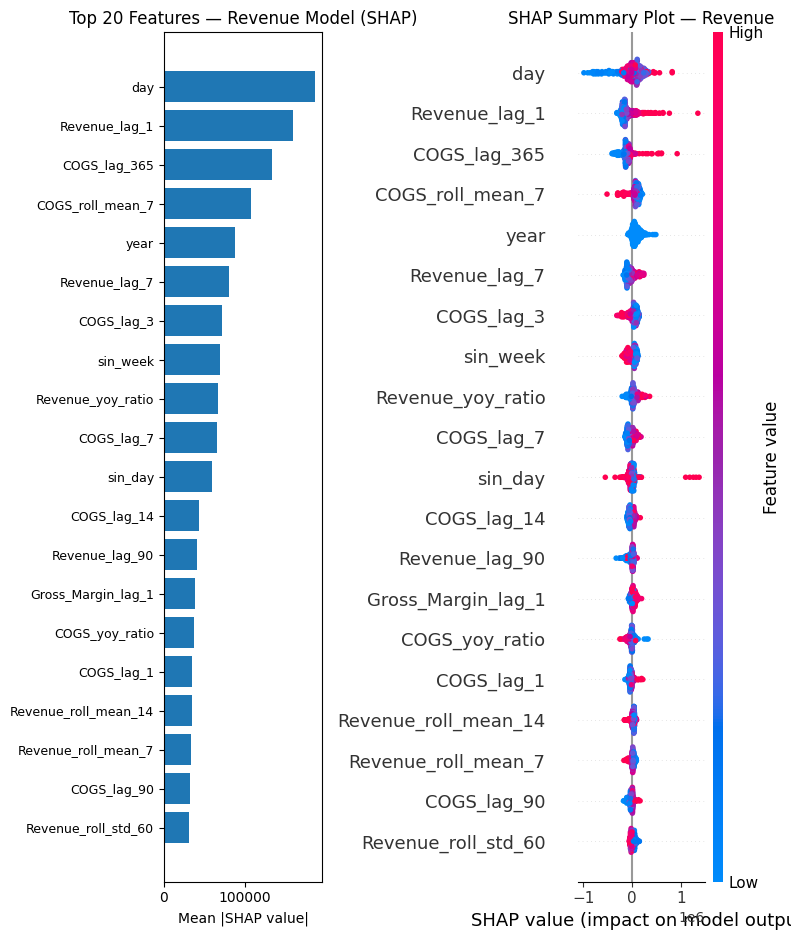

SHAP plot saved.

=== Business Interpretation (dùng cho báo cáo) ===
  day                                 SHAP=   185,755  → Feature có ảnh hưởng đến dự báo
  Revenue_lag_1                       SHAP=   159,202  → Doanh thu ngày trước là signal dự báo mạnh
  COGS_lag_365                        SHAP=   132,709  → Doanh thu ngày trước là signal dự báo mạnh
  COGS_roll_mean_7                    SHAP=   107,420  → Xu hướng ngắn hạn capture được pattern tuần/tháng
  year                                SHAP=    87,247  → Trend tăng trưởng theo năm rõ rệt
  Revenue_lag_7                       SHAP=    79,898  → Doanh thu ngày trước là signal dự báo mạnh
  COGS_lag_3                          SHAP=    71,008  → Doanh thu ngày trước là signal dự báo mạnh
  sin_week                            SHAP=    68,871  → Feature có ảnh hưởng đến dự báo
  Revenue_yoy_ratio                   SHAP=    67,098  → Feature có ảnh hưởng đến dự báo
  COGS_lag_7                          SHAP=    65,182  → Doanh thu

In [25]:
# %% [13] — SHAP Explainability (cho báo cáo kỹ thuật — 8 điểm)
print("\n[SHAP] Computing feature importance for Revenue model (LightGBM)...")
 
lgb_rev_model = fitted_rev['lgb']
explainer = shap.TreeExplainer(lgb_rev_model)
# Dùng val set để explain (không dùng train để tránh overfitting explanation)
shap_values = explainer.shap_values(X_val_rev)
 
# Global feature importance
shap_df = pd.DataFrame({
    'feature': FEATURES_REV,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
 
print("\nTop 15 features by SHAP importance:")
print(shap_df.head(15).to_string(index=False))
 
# Plot SHAP summary (lưu file)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# Bar chart top 20
top20 = shap_df.head(20)
axes[0].barh(top20['feature'][::-1], top20['mean_abs_shap'][::-1])
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Top 20 Features — Revenue Model (SHAP)')
axes[0].tick_params(axis='y', labelsize=9)
 
# SHAP beeswarm (dùng matplotlib backend)
shap.summary_plot(shap_values, X_val_rev, feature_names=FEATURES_REV,
                  max_display=20, show=False, plot_type='dot')
plt.title('SHAP Summary Plot — Revenue', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'outputs', 'shap_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved.")
 
# Business language interpretation
print("\n=== Business Interpretation (dùng cho báo cáo) ===")
for _, row in shap_df.head(10).iterrows():
    feat = row['feature']
    val  = row['mean_abs_shap']
    # Tự động sinh nhận xét dựa trên tên feature
    if 'lag' in feat:
        note = "Doanh thu ngày trước là signal dự báo mạnh"
    elif 'roll' in feat or 'ewm' in feat:
        note = "Xu hướng ngắn hạn capture được pattern tuần/tháng"
    elif 'tet' in feat or 'holiday' in feat:
        note = "Ngày lễ/Tết tác động đáng kể đến doanh thu"
    elif 'promo' in feat or 'discount' in feat:
        note = "Chiến dịch khuyến mãi ảnh hưởng trực tiếp đến doanh số"
    elif 'year' in feat:
        note = "Trend tăng trưởng theo năm rõ rệt"
    elif 'month' in feat or 'quarter' in feat:
        note = "Seasonality theo tháng/quý"
    elif 'weekend' in feat:
        note = "Hành vi mua sắm cuối tuần khác ngày thường"
    else:
        note = "Feature có ảnh hưởng đến dự báo"
    print(f"  {feat:<35} SHAP={val:>10,.0f}  → {note}")
 

In [28]:
# %% [14] — Retrain trên FULL data (train + val) trước khi predict test
print("\n=== Retraining on FULL data (2012–2022) ===")
full_mask = data['Date'] <= '2022-12-31'
 
X_full_rev  = data.loc[full_mask, FEATURES_REV]
y_full_rev  = data.loc[full_mask, 'Revenue']
X_full_cogs = data.loc[full_mask, FEATURES_COGS]
y_full_cogs = data.loc[full_mask, 'COGS']

# Refit Prophet trên full data
print("[Prophet] Refitting on full data...")
prophet_rev_full  = fit_prophet(data[full_mask], 'Revenue', vn_holidays)
prophet_cogs_full = fit_prophet(data[full_mask], 'COGS',    vn_holidays)
 
prophet_rev_full_tr  = prophet_predict(prophet_rev_full,  data.loc[full_mask, 'Date'])
prophet_cogs_full_tr = prophet_predict(prophet_cogs_full, data.loc[full_mask, 'Date'])
 
res_rev_full  = y_full_rev.values  - prophet_rev_full_tr
res_cogs_full = y_full_cogs.values - prophet_cogs_full_tr

# OOF trên full data cho meta-learner
print("[Revenue] OOF on full data for meta-learner...")
models_rev_final  = get_models()
models_cogs_final = get_models()
 
oof_rev_full  = train_oof_stack(
    X_full_rev, pd.Series(res_rev_full, index=X_full_rev.index),
    models_rev_final, n_splits=5, gap=30
)
oof_cogs_full = train_oof_stack(
    X_full_cogs, pd.Series(res_cogs_full, index=X_full_cogs.index),
    models_cogs_final, n_splits=5, gap=30
)
 
print("[Revenue] Final base models + meta-learner...")
fitted_rev_final,  meta_rev_final  = train_meta_and_base(
    X_full_rev,  pd.Series(res_rev_full,  index=X_full_rev.index),
    models_rev_final,  oof_rev_full
)
fitted_cogs_final, meta_cogs_final = train_meta_and_base(
    X_full_cogs, pd.Series(res_cogs_full, index=X_full_cogs.index),
    models_cogs_final, oof_cogs_full
)
print("Full retrain complete.")
 


=== Retraining on FULL data (2012–2022) ===
[Prophet] Refitting on full data...


23:45:15 - cmdstanpy - INFO - Chain [1] start processing
23:45:16 - cmdstanpy - INFO - Chain [1] done processing
23:45:16 - cmdstanpy - INFO - Chain [1] start processing
23:45:17 - cmdstanpy - INFO - Chain [1] done processing


[Revenue] OOF on full data for meta-learner...
  TimeSeriesSplit OOF — 5 folds, gap=30 days
    Fold 1: MAE = lgb=1,128,529 | xgb=1,053,705 | cat=1,065,868
    Fold 2: MAE = lgb=846,798 | xgb=829,782 | cat=876,683
    Fold 3: MAE = lgb=938,999 | xgb=868,997 | cat=857,638
    Fold 4: MAE = lgb=774,028 | xgb=690,856 | cat=717,125
    Fold 5: MAE = lgb=643,415 | xgb=635,175 | cat=649,080
  TimeSeriesSplit OOF — 5 folds, gap=30 days
    Fold 1: MAE = lgb=966,777 | xgb=879,174 | cat=864,872
    Fold 2: MAE = lgb=762,098 | xgb=754,757 | cat=778,610
    Fold 3: MAE = lgb=780,626 | xgb=746,789 | cat=729,626
    Fold 4: MAE = lgb=638,843 | xgb=594,269 | cat=607,952
    Fold 5: MAE = lgb=578,455 | xgb=567,494 | cat=585,069
[Revenue] Final base models + meta-learner...
  Meta-learner weights: {'lgb': np.float64(-0.133), 'xgb': np.float64(0.857), 'cat': np.float64(0.203)}
  Meta-learner weights: {'lgb': np.float64(-0.12), 'xgb': np.float64(0.622), 'cat': np.float64(0.385)}
Full retrain complete.


In [29]:
# %% [15] — Recursive Forecast cho Test Period
def recursive_forecast(historical_df, forecast_dates,
                        prophet_rev_m, prophet_cogs_m,
                        fitted_rev_m, meta_rev_m,
                        fitted_cogs_m, meta_cogs_m,
                        features_rev, features_cogs,
                        lags, windows, promo_features_df,
                        tet_dates_set, holiday_mmdd):
    """
    Recursive forecast: dùng predicted values làm lag features cho ngày tiếp theo.
    """
    hist = historical_df.copy().reset_index(drop=True)
    predictions = []
 
    for forecast_date in forecast_dates:
        feats = {}
 
        # Date features
        feats['year']           = forecast_date.year
        feats['month']          = forecast_date.month
        feats['day']            = forecast_date.day
        feats['quarter']        = (forecast_date.month - 1) // 3 + 1
        feats['dayofweek']      = forecast_date.dayofweek
        feats['dayofyear']      = forecast_date.dayofyear
        feats['weekofyear']     = forecast_date.isocalendar().week
        feats['is_weekend']     = int(forecast_date.dayofweek in [5, 6])
        feats['is_month_start'] = int(forecast_date.day == 1)
        feats['is_month_end']   = int((forecast_date + pd.Timedelta(days=1)).month != forecast_date.month)
        feats['is_quarter_end'] = int(feats['is_month_end'] and forecast_date.month in [3, 6, 9, 12])
        doy = feats['dayofyear']
        dow = feats['dayofweek']
        mon = feats['month']
        feats['sin_day']   = np.sin(2 * np.pi * doy / 365.25)
        feats['cos_day']   = np.cos(2 * np.pi * doy / 365.25)
        feats['sin_week']  = np.sin(2 * np.pi * dow / 7)
        feats['cos_week']  = np.cos(2 * np.pi * dow / 7)
        feats['sin_month'] = np.sin(2 * np.pi * mon / 12)
        feats['cos_month'] = np.cos(2 * np.pi * mon / 12)
        feats['is_holiday']    = int(forecast_date.strftime('%m-%d') in holiday_mmdd)
        feats['is_tet_period'] = int(forecast_date in tet_dates_set)
 
        # Promo features từ data thật
        day_promo = promo_features_df[promo_features_df['Date'] == forecast_date]
        promo_cols = [c for c in promo_features_df.columns if c != 'Date']
        for col in promo_cols:
            feats[col] = day_promo[col].values[0] if len(day_promo) > 0 else 0
 
        # COGS lag/rolling
        for lag in lags:
            idx = len(hist) - lag
            feats[f'COGS_lag_{lag}'] = hist['COGS'].iloc[idx] if idx >= 0 else hist['COGS'].mean()
        for w in windows:
            tail = hist['COGS'].iloc[-w:] if len(hist) >= w else hist['COGS']
            feats[f'COGS_roll_mean_{w}'] = tail.mean()
            feats[f'COGS_roll_std_{w}']  = tail.std() if len(tail) > 1 else 0
        for span in [7, 30]:
            feats[f'COGS_ewm_{span}'] = hist['COGS'].ewm(span=span).mean().iloc[-1]
 
        X_cogs = pd.DataFrame([feats]).reindex(columns=features_cogs, fill_value=0)
        p_prophet_cogs = prophet_predict(prophet_cogs_m, [forecast_date])[0]
        base_cogs = np.column_stack([m.predict(X_cogs) for m in fitted_cogs_m.values()])
        res_cogs  = meta_cogs_m.predict(base_cogs)[0]
        pred_cogs = max(0.0, p_prophet_cogs + res_cogs)
 
        # Revenue lag/rolling
        for lag in lags:
            idx = len(hist) - lag
            feats[f'Revenue_lag_{lag}'] = hist['Revenue'].iloc[idx] if idx >= 0 else hist['Revenue'].mean()
        for w in windows:
            tail = hist['Revenue'].iloc[-w:] if len(hist) >= w else hist['Revenue']
            feats[f'Revenue_roll_mean_{w}'] = tail.mean()
            feats[f'Revenue_roll_std_{w}']  = tail.std() if len(tail) > 1 else 0
        for span in [7, 30]:
            feats[f'Revenue_ewm_{span}'] = hist['Revenue'].ewm(span=span).mean().iloc[-1]
 
        rev_l1  = hist['Revenue'].iloc[-1]
        cogs_l1 = hist['COGS'].iloc[-1]
        feats['Gross_Margin_lag_1'] = (rev_l1 - cogs_l1) / (rev_l1 + 1)
        rev_365 = hist['Revenue'].iloc[-365] if len(hist) >= 365 else hist['Revenue'].mean()
        cogs_365= hist['COGS'].iloc[-365]    if len(hist) >= 365 else hist['COGS'].mean()
        feats['Revenue_yoy_ratio'] = rev_l1  / (rev_365  + 1)
        feats['COGS_yoy_ratio']    = cogs_l1 / (cogs_365 + 1)
 
        X_rev = pd.DataFrame([feats]).reindex(columns=features_rev, fill_value=0)
        p_prophet_rev = prophet_predict(prophet_rev_m, [forecast_date])[0]
        base_rev = np.column_stack([m.predict(X_rev) for m in fitted_rev_m.values()])
        res_rev  = meta_rev_m.predict(base_rev)[0]
        pred_rev = max(0.0, p_prophet_rev + res_rev)
 
        predictions.append({'Date': forecast_date, 'Revenue': pred_rev, 'COGS': pred_cogs})
 
        # Append predicted row vào history cho lần tiếp theo
        new_row = pd.DataFrame([{
            'Date': forecast_date, 'Revenue': pred_rev, 'COGS': pred_cogs
        }])
        hist = pd.concat([hist[['Date', 'Revenue', 'COGS']], new_row], ignore_index=True)
 
    return pd.DataFrame(predictions)
 

In [30]:
# %% [16] — Generate Test Predictions
print("\n=== Generating Test Predictions ===")
test_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
print(f"Forecasting {len(test_dates)} days...")
 
historical_data = data[full_mask][['Date', 'Revenue', 'COGS']].copy()
 
submission = recursive_forecast(
    historical_data, test_dates,
    prophet_rev_full,  prophet_cogs_full,
    fitted_rev_final,  meta_rev_final,
    fitted_cogs_final, meta_cogs_final,
    FEATURES_REV, FEATURES_COGS,
    lags, windows, promo_features,
    tet_dates_set, holiday_mmdd,
)
 
# Align với sample_submission (đúng thứ tự, đúng số dòng)
submission = submission.merge(sample_sub[['Date']], on='Date', how='right')
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission = submission[['Date', 'Revenue', 'COGS']]
 
out_path = os.path.join(DATA_DIR, 'outputs', 'submission_improved.csv')
submission.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Submission shape: {submission.shape}")
print(submission.head(10))


=== Generating Test Predictions ===
Forecasting 548 days...
Saved: ../data\outputs\submission_improved.csv
Submission shape: (548, 3)
         Date       Revenue          COGS
0  2023-01-01  1.985424e+06  2.197329e+06
1  2023-01-02  1.416661e+06  1.535081e+06
2  2023-01-03  1.891964e+06  1.943259e+06
3  2023-01-04  2.224101e+06  1.967506e+06
4  2023-01-05  1.746811e+06  1.636611e+06
5  2023-01-06  1.595210e+06  1.420780e+06
6  2023-01-07  1.159684e+06  1.060829e+06
7  2023-01-08  1.152886e+06  1.041314e+06
8  2023-01-09  9.630920e+05  8.505143e+05
9  2023-01-10  8.513761e+05  9.381503e+05


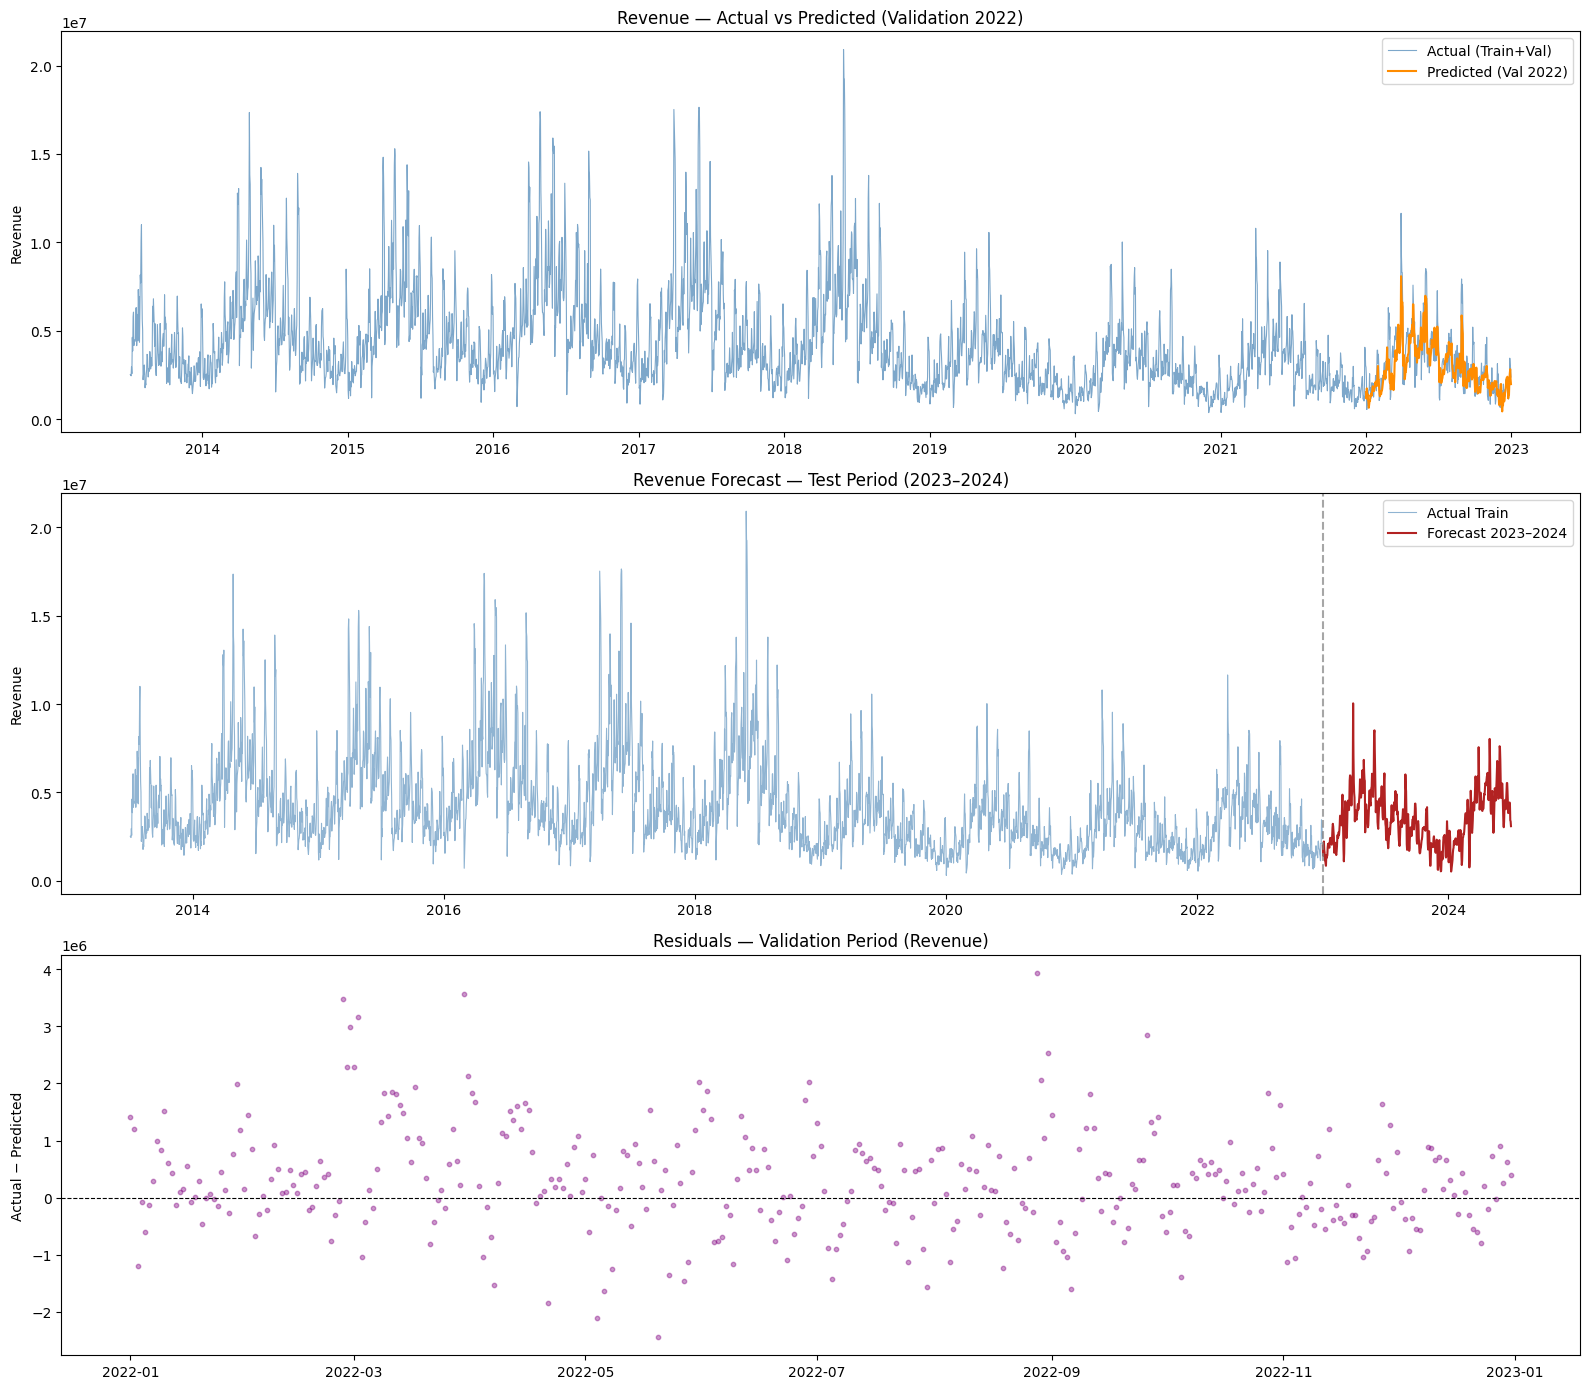


All done!


In [31]:
# %% [17] — Visualizations
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
 
# (a) Actual vs Predicted — Validation period
val_dates = data.loc[val_mask, 'Date']
axes[0].plot(data.loc[full_mask, 'Date'], data.loc[full_mask, 'Revenue'],
             label='Actual (Train+Val)', color='steelblue', alpha=0.7, linewidth=0.8)
axes[0].plot(val_dates, val_rev_pred, label='Predicted (Val 2022)',
             color='darkorange', linewidth=1.5)
axes[0].set_title('Revenue — Actual vs Predicted (Validation 2022)')
axes[0].set_ylabel('Revenue')
axes[0].legend()
 
# (b) Test forecast
axes[1].plot(data.loc[full_mask, 'Date'], data.loc[full_mask, 'Revenue'],
             label='Actual Train', color='steelblue', alpha=0.6, linewidth=0.8)
axes[1].plot(pd.to_datetime(submission['Date']), submission['Revenue'],
             label='Forecast 2023–2024', color='firebrick', linewidth=1.5)
axes[1].axvline(pd.Timestamp('2023-01-01'), color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Revenue Forecast — Test Period (2023–2024)')
axes[1].set_ylabel('Revenue')
axes[1].legend()
 
# (c) Residuals validation
residuals_plot = y_val_rev.values - val_rev_pred
axes[2].scatter(val_dates, residuals_plot, alpha=0.4, s=10, color='purple')
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Residuals — Validation Period (Revenue)')
axes[2].set_ylabel('Actual − Predicted')
 
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'outputs', 'forecast_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\nAll done!")